In [1]:
# Compute approximate Koopman linear system for a system with input
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt
import GPKoopman as gpk

### CarSim Data
States are given by - $ x = [\delta_s, e_y, e_{\psi}, V_x, V_y, \omega_z]^T $
 - $\delta_s$ - arc length traveled in that time-step
 - $\epsilon_y$ - deviation from the road median
 - $\epsilon_{\psi}$ - angular deviation with the curvature of the road (assumed straight in basic dataset)
 - $V_x$ - Velocity along the path
 - $V_y$ - Velocity perpendicular to path
 - $\omega_w$ - Yaw velocity

The Inputs are given by - $ u = [F_{x,f}, F_{x,r}, \delta_s] $
 - $F_{x,f}$ - Longitudinal force on front tire
 - $F_{x,r}$ - Longitudinal force on rear tire
 - $\delta_s$ - Steering angle of the wheels



In [2]:
# Read dataframes from csv files
df_Xtrain = pd.read_csv("Data/X_scaled.csv", header=None)
df_Ytrain = pd.read_csv('Data/Y_scaled.csv', header=None)
df_Utrain = pd.read_csv('Data/U_scaled.csv', header=None)
df_Xtest = pd.read_csv('Data/testX_scaled.csv', header=None)
df_Ytest = pd.read_csv('Data/testY_scaled.csv', header=None)
df_Utest = pd.read_csv('Data/testU_scaled.csv', header=None)
df_dataparams = pd.read_csv('Data/DataParams.csv', header=None)

# Convert the Pandas dataframes to PyTorch tensors
Xtrain = torch.from_numpy(df_Xtrain.values)
Ytrain = torch.from_numpy(df_Ytrain.values)
Utrain = torch.from_numpy(df_Utrain.values)
Xtest = torch.from_numpy(df_Xtest.values)
Ytest = torch.from_numpy(df_Ytest.values)
Utest = torch.from_numpy(df_Utest.values)
dataparams = torch.from_numpy(df_dataparams.values)
ts = dataparams[0]
train_Xmean = dataparams[1:7]
train_Ymean = dataparams[7:13]
train_Umean = dataparams[13:16]
train_Xsd = dataparams[16:22]
train_Ysd = dataparams[22:28]
train_Usd = dataparams[28:31]
test_Xmean = dataparams[31:37]
test_Ymean = dataparams[37:43]
test_Umean = dataparams[43:46]
test_Xsd = dataparams[46:52]
test_Ysd = dataparams[52:58]
test_Usd = dataparams[58:61]

print(f'Finished loading CarSim Training and Test datasets.')

Finished loading CarSim Training and Test datasets.


In [3]:
# Cost function definition

def get_cost_nonautonomous(Z, X, Xplus, U, Xgrid, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function as defined in the Word doc, with different GP Kernel hyperparameters for
    each observable.

    Args:
        Z: Tensor of shape (r**n, p), decision variable, required grad
        X: Tensor of shape (n, nT*N), dataset of N steps from all trajectories
        Xplus: Tensor of shape (n, nT*N), 1 time-step shifted dataset
        U: Tensor of shape (q, nT*N), control sequence for N steps from all trajectories
        Xtrain: Tensor of shape (n, r**n), flattened set of gridpoints for training GPOs
        manager: Object of class GPObservablesManager (manager for all Gaussian Process based Observable functions)
        nT: float, number of trajectories in training dataset
        lambda1: float, Weighting for multi-step prediction error minimization term
        lambda2: float, Weightining for Reconstruction Error penalty term
    """
    
    N = (X.shape[1])//nT    # Number of time steps in each trajectory
    p = Z.shape[1]          # Number of Observables
    rpn = Z.shape[0]      # Decision Horizon
    n = X.shape[0]          # Dimensionality of original system
    q = U.shape[0]

    for i in range(p):
        manager.train_observable(i, Xgrid, Z[:,i])

    # For current definition of GPOs
    # Training: Xtrain = dimensions x samples
    # Training: Ytrain = samples x (dimensions=1)
    # Prediction: Xquery = dimensions x num-query = Input
    # Prediction: Yquery = num-query x (dimensions=1) = Output

    # Lifting X and Xplus to higher dimension using trained GPOs
    M = torch.empty((p,N*nT))
    Mplus = torch.empty((p,N*nT))
    
    #Mall = torch.empty((p,(N+1)*nT))
    for i in range(p):
        M[i,:] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i,:] = torch.transpose(manager.predict_mean(i, Xplus), dim0=0, dim1=-1)
    
    # Compute A(z) and B(z)
    Mfull = torch.vstack((X, M, U))
    Mplusfull = torch.vstack((Xplus, Mplus))

    M_pinv = torch.linalg.pinv(Mfull)
    #Cz = X @ M_pinv
    Kz = Mplusfull @ M_pinv
    Az = Kz[:, 0:(n+p)]
    Bz = Kz[:, (n+p):]
    C = torch.zeros((n,n+p), dtype=Az.dtype)
    for i in range(n):
        C[i,i] = 1.
    
    # Cost term 1: Multi-Trajectory Prediction Error Minimization
    NormPEM = 0.0
    uterm = Bz @ U

    xpred_list = []  # Accumulate predictions instead of in-place updates
    zpred_list = []  # Store zpred across trajectories

    for j in range(nT):
        z_traj = [Mfull[0:(n+p), j*N].clone()]  # Start with initial condition
        for k in range(N):
            z_next = Az @ z_traj[-1] + uterm[:, j*N + k]
            z_traj.append(z_next)
        
        # Store trajectory
        z_traj_tensor = torch.stack(z_traj, dim=1)  # Stack along time dimension
        zpred_list.append(z_traj_tensor)

        # Compute x predictions
        x_traj = C @ z_traj_tensor[:, :-1]  # Ignore last time-step for x
        xpred_list.append(x_traj)

    # Concatenate all trajectories
    zpred = torch.cat(zpred_list, dim=1)
    xpred = torch.cat(xpred_list, dim=1)

    # Compute NormPEM with a small epsilon for stability
    NormPEM = torch.sum(torch.linalg.norm((X[:,0:xpred.shape[1]] - xpred), dim=1) + 1e-6)

    # Weighted sum of terms
    cost = (lambda1 * NormPEM / (N * nT))
    return cost


In [4]:
# Initialize Optimization
# Original and Koopman Model parameters

n = Xtrain.shape[0]
N = Xtest.shape[1]
nT = Xtrain.shape[1]//N

p = 40  # number of lifted states
r = 20   # resolution along all dimensions

Xgrid = torch.cat([Xtrain[:,j*N:j*N+r] for j in range(nT)],dim=1)         # Data matrix from original system

# Initialize Decision Variables
Z = torch.rand(r*nT, p, requires_grad=True, dtype=torch.float64)   # Shape: (r**n)-by-p

#print(f'Xgrid, Z and Xtrain data-types are: {Xgrid.dtype}, {Z.dtype} and {Xtrain.dtype}')

ObsManager = gpk.GPObservablesManager()
for i in range(p):
    ObsManager.add_observable(index=i, d=n, ns=r*nT, kernel_types=['Gaussian'],noise=1e-6)

ObsManager.set_random_hyperparameters(scale=1.0)
print('Observable Hyperparameters have been randomized')

#cost = get_cost_nonautonomous(Z, Xtrain.float(), Ytrain.float(), Utrain.float(), Xgrid.float(), ObsManager, nT=nT, lambda1=1.)
cost = get_cost_nonautonomous(Z, Xtrain, Ytrain, Utrain, Xgrid, ObsManager, nT=nT, lambda1=1.)

Observable Hyperparameters have been randomized


Total Observables available: 40
Starting Iteration Loop!
Iteration 1/200 with 0 Insignificant Iterations
Cost: 0.26941255446269946
Iteration 2/200 with 0 Insignificant Iterations
Cost: 0.25367512918949947
Iteration 3/200 with 0 Insignificant Iterations
Cost: 0.23591935561376512
Iteration 4/200 with 0 Insignificant Iterations
Cost: 0.22826190232797258
Iteration 5/200 with 0 Insignificant Iterations
Cost: 0.22089399305877747
Iteration 6/200 with 0 Insignificant Iterations
Cost: 0.21452489030945648
Iteration 7/200 with 0 Insignificant Iterations
Cost: 0.20916128129062686
Iteration 8/200 with 0 Insignificant Iterations
Cost: 0.20420344324276712
Iteration 9/200 with 0 Insignificant Iterations
Cost: 0.19858561412633852
Iteration 10/200 with 0 Insignificant Iterations
Cost: 0.19824232611903714
Iteration 11/200 with 0 Insignificant Iterations
Cost: 0.21495671771429675
Iteration 12/200 with 0 Insignificant Iterations
Cost: 0.20627447492805226
Iteration 13/200 with 0 Insignificant Iterations
Cos

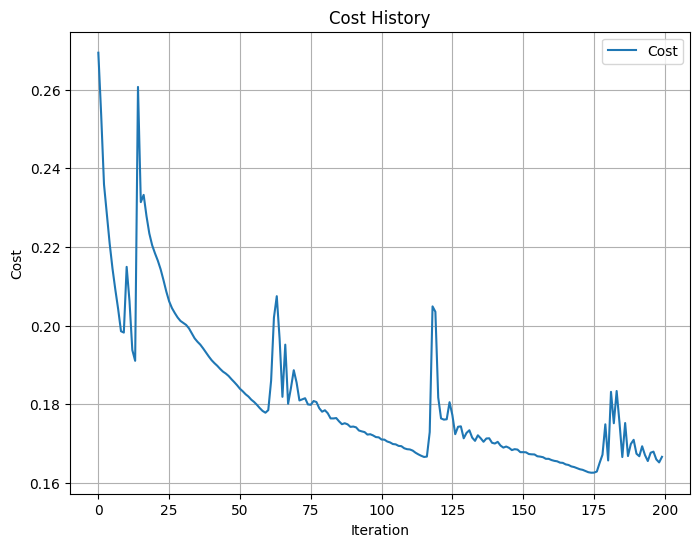

In [5]:
# Optimization Section
print(f'Total Observables available: {gpk.GPObservable.count_Observables()}')

# Optimization Parameters
max_iter = 200
learn_rate = 0.02   # Learning Rate    
err_thresh = 0.001    # Target Cost
patience = 40       # Number of iterations to monitor for significant change
min_delta = 1e-5    # Minimum required decrease in cost for significance

optimizer = torch.optim.Adam([Z, ObsManager.get_all_params()], lr=learn_rate)    # Optimizer  

print('Starting Iteration Loop!')
cost_history = []
iter = 0
count_insignificant = 0
#torch.autograd.set_detect_anomaly(True)
while iter < max_iter:
    optimizer.zero_grad()  # Clear gradients

    # Compute cost
    cost = get_cost_nonautonomous(Z, Xtrain, Ytrain, Utrain, Xgrid, ObsManager, nT=nT, lambda1=10.)
    
    cost_history.append(cost.item())

    # Backpropagation
    cost.backward(retain_graph=True)

    # Optimization step
    optimizer.step()

    print(f"Iteration {iter + 1}/{max_iter} with {count_insignificant} Insignificant Iterations")
    print(f"Cost: {cost.item()}")

    # Stopping conditions
    if cost.item() < err_thresh:
        print("Stopping: Error threshold reached.")
        break

    # Check for significant improvement
    if iter > patience:
        error_change = cost_history[-patience] - cost_history[-1]
        if error_change < min_delta or error_change < 0:
            count_insignificant += 1
        else:
            count_insignificant = 0

        if count_insignificant >= patience:
            print("Stopping: No significant improvement over consecutive iterations.")
            break

    # Increment iteration
    iter += 1


if iter == max_iter:
    print(f'Stopping: Reached maximum number of iterations = {iter}.')


optimal_Z = Z.detach()

print('Optimization Complete.')
print("Final Cost:", cost.item())

#plt.ioff()
#plt.show()

# Plot cost history
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Cost")
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()

In [6]:
# Get Koopman System Model
# Use Optimal Z values to Build GP Models and Optimal A and Z matrices
optimal_Z = Z.detach()
for i in range(p):
    ObsManager.train_observable(i, Xgrid, optimal_Z[:,i])  # train GP Observables with Optimal Z outputs

ObsManager.optimize_hyperparameters()   # Optimize Kernel hyperparameters for Optimal training data

# Plot Optimal GP Response Shape within Domain
#ObsManager.plot_observables(range_x=(-3,3), range_y=(-3,3))

ObsList = [i for i in range(p)]


A, B, C = gpk.getKoopman_control(ObsManager, ObsList, X=Xtrain, Xplus=Ytrain, U=Utrain, nT=nT, stateAug=True)

In [7]:
#initial_state = torch.tensor([244.4171, 271.7376], dtype=torch.float64)
val_steps = Xtest.shape[1]

Xq = Xtest[:, 0].view(n,1)

#Xq[:,0] = torch.tensor([0.95*244.4171, 0.95*271.7376])    # IC for Lotka-Volterra
# Validation IC for Duffing Oscillator from Clemson paper = -1.0993779695641197, -0.9956159478504363

# Simulate the system
time = torch.arange(0., 0.05 * val_steps, 0.05)

Zmean = torch.empty((p,1))
Zcv = torch.empty((p,1))

for i in range(p):
    Zmean[i,0] = ObsManager.predict_mean(i, Xq)
    Zcv[i,0] = ObsManager.predict_covariance(i, Xq)

Z0 = torch.vstack((Xq, Zmean))
Z0cv = torch.vstack((torch.zeros((n,1), device=Zcv.device), Zcv))
Z0cv = torch.diag(Z0cv[:,0])    # vector argument returns a matrix, matrix argument (even shape (n,1)) returns vector shape=(n,)

TrajZ, TrajZcv, Xhat, Xcvhat = gpk.sim_LTI_nonautonomous(Z0.float(), A.float(), B.float(), C.float(), Utest.float(), num_steps=val_steps, ts=None, x0cv=Z0cv.float())
Xhat = Xhat.detach().numpy()
Xcvhat = Xcvhat.detach().numpy()


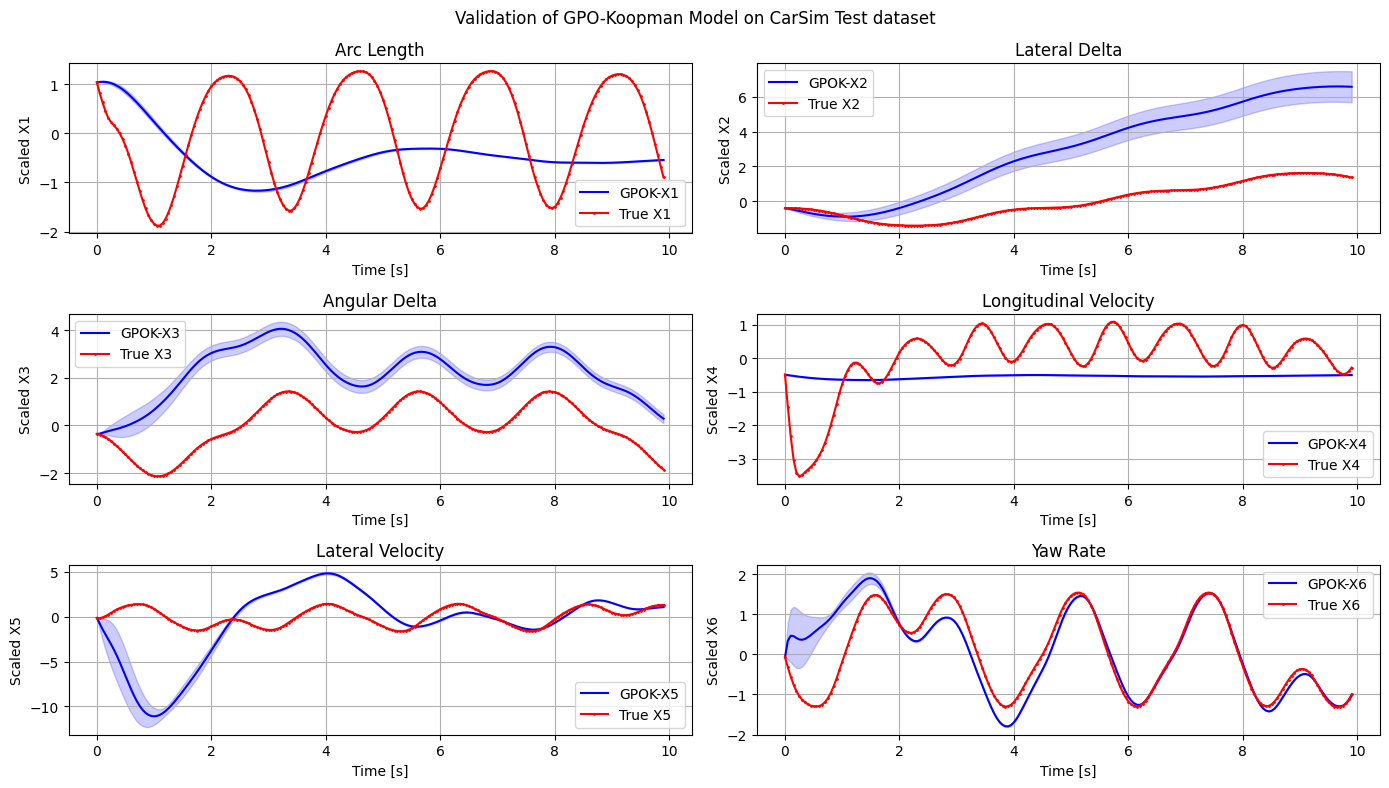

In [8]:
fig, ax = plt.subplots(3,2, figsize=(14,8))

st_names = ['Arc Length', 'Lateral Delta', 'Angular Delta', 'Longitudinal Velocity', 'Lateral Velocity', 'Yaw Rate']

for i in range(n):
    ax.flat[i].fill_between(time, Xhat[i,:] - 3*Xcvhat[i,i,:]**0.5, Xhat[i,:] + 3*Xcvhat[i,i,:]**0.5, alpha=0.2, color='blue')
    ax.flat[i].plot(time, Xhat[i,:], color='blue', label=f'GPOK-X{i+1}')
    ax.flat[i].plot(time, Xtest[i,:], label=f'True X{i+1}', color='red', marker='o', ms=1.)
    ax.flat[i].legend()
    ax.flat[i].grid(True)
    ax.flat[i].set_xlabel('Time [s]')
    ax.flat[i].set_ylabel(f'Scaled X{i+1}')
    ax.flat[i].set_title(f'{st_names[i]}')

plt.suptitle('Validation of GPO-Koopman Model on CarSim Test dataset')
plt.tight_layout()
plt.show()


In [12]:
import scipy.io
import torch
import numpy as np

# Load the .mat file
mat_data = scipy.io.loadmat("F:\ALLCODE\sloshing_xdata.mat")

data_tensor = torch.from_numpy(mat_data["xval"]).float().flatten()

SimData = data_tensor.view(-1, 1, 47*2)

torch.manual_seed(42)

SimData = SimData[torch.randperm(SimData.shape[0])]

data = {
    "trajectories": SimData,
    "sample_time": 0.033,
    "num_trajectories": SimData.shape[0],
    "num_steps": SimData.shape[2] - 1,
}

torch.save(data, "Data/DataAuto_Sloshing.pt")

<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
C:\Users\abhig\AppData\Local\Temp\ipykernel_28308\103979471.py:6: SyntaxWarning: invalid escape sequence '\A'
  mat_data = scipy.io.loadmat("F:\ALLCODE\sloshing_xdata.mat")


In [8]:
SimData.shape

torch.Size([75, 1, 94])

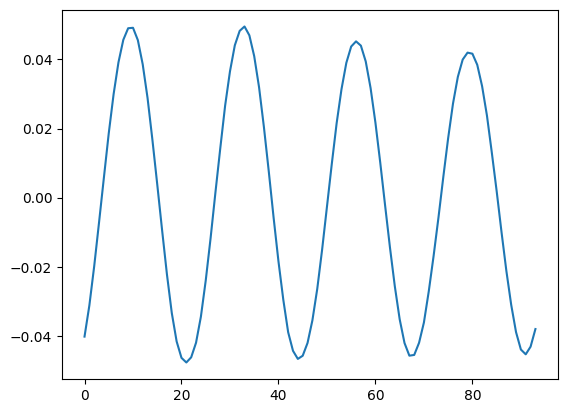

In [11]:
from matplotlib import pyplot as plt

plt.plot(SimData[6, 0, :])